# Figure 4. Controlled known-target comparison

Reproduces Figure 4 (§5.1.5) of *A Spectrally Damped Tensor Randomized
Kaczmarz Method for Doubly Noisy Tensor Systems*.

- **Experiment 5.1.5** — controlled known-target comparison between standard TRK and SD-TRK
  under a sparse ill-conditioned doubly noisy setting (`known_target_comparison.png`)

**Common setting.** In each Monte Carlo realization, both methods are run on the **same**
ground truth $\mathcal{X}^\star$, the same observed $\tilde{\mathcal{A}},\tilde{\mathcal{B}}$, and the
same randomized row-selection sequence $\mathcal{I}_T=\{i_1,\ldots,i_T\}$; across realizations,
the system and sequence are regenerated independently. The comparison is therefore **paired**,
attributing discrepancies to the intrinsic update mechanisms rather than sampling variability.
Dimensions $(n_1,n_2,n_3,n_4)=(20,10,5,5)$; the system uses the same lateral-slice scaling
construction as §5.1.4 with factors decaying geometrically from $1$ to $3\times 10^{-2}$, and the
sparse ground truth concentrates all signal energy in the leading $5$ active rows (remaining rows
identically zero). Noise: $\delta_A=0.01$ (minor operator perturbation), $\delta_B=0.5$ (substantial
observation noise). Both algorithms start from $\mathcal{X}^0=\mathbf{0}$ and run $T=2000$
iterations; trajectories are averaged over $10$ paired realizations. The figure compares the true
reconstruction errors of both methods together with the observable SD-TRK residual (the standard
TRK residual is omitted for readability).

**SD-TRK** uses $\omega=0.8$ with the slice-dependent damping rule

$$\lambda^{(k)}=\lambda_{\mathrm{floor}}+\lambda_{\mathrm{scale}}\,(\delta_A^2+\delta_B^2)\,\frac{\|\hat{\tilde{A}}^{(k)}\|_F^2}{n_1},\qquad k=1,\ldots,n_3,\qquad \lambda_{\mathrm{scale}}=50.0,\ \lambda_{\mathrm{floor}}=10^{-6}.$$

**Expected result.** Standard TRK decreases early, then exhibits pronounced semi-convergence:
it fits noise-contaminated components in zero-signal directions and near-zero singular values
amplify the perturbation, driving the true error toward approximately $10.9761$. Under the same
row-sampling sequence, SD-TRK decreases nearly monotonically and stabilizes near $2.9251$ —
about $3.75$ times smaller — with its residual closely aligned with the stabilization phase.
(Reported values are averages over the last $200$ iterations.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
def t_prod(A, B):
    # t-product: FFT along mode 3 -> slice-wise matmul -> inverse FFT (Appendix A)
    n1, _, n3 = A.shape
    n4 = B.shape[1]
    A_hat = np.fft.fft(A, axis=2)
    B_hat = np.fft.fft(B, axis=2)
    C_hat = np.zeros((n1, n4, n3), dtype=complex)
    for k in range(n3):
        C_hat[:, :, k] = A_hat[:, :, k] @ B_hat[:, :, k]
    return np.fft.ifft(C_hat, axis=2).real


def t_transpose(A):
    # conjugate transpose: transpose each frontal slice, then reverse slices 2..n3
    n1, n2, n3 = A.shape
    At = np.zeros((n2, n1, n3), dtype=A.dtype)
    At[:, :, 0] = A[:, :, 0].T
    for k in range(1, n3):
        At[:, :, k] = A[:, :, n3 - k].T
    return At


def t_inv(tube):
    # tube inverse: reciprocal per Fourier frequency (nonzero by Assumption 2.9)
    hat = np.fft.fft(tube, axis=2)
    return np.fft.ifft(1.0 / hat, axis=2).real


def tnorm(T):
    # Frobenius norm of a tensor
    return np.linalg.norm(T.reshape(-1))


def trk_step(X, Aslice, Bslice):
    # standard TRK update: X <- X + A_i^* (A_i A_i^*)^{-1} (B_i - A_i X)
    resid = Bslice - t_prod(Aslice, X)
    At = t_transpose(Aslice)
    scale = t_inv(t_prod(Aslice, At))
    return X + t_prod(At, t_prod(scale, resid))


def sdtrk_step(X, Aslice, Bslice, lambdas, omega):
    # SD-TRK update, slice-wise in the Fourier domain (Algorithm 1):
    # X^(k) <- X^(k) - omega * a^* (a a^* + lambda_k)^{-1} (a X^(k) - b)
    A_hat = np.fft.fft(Aslice, axis=2)
    B_hat = np.fft.fft(Bslice, axis=2)
    X_hat = np.fft.fft(X, axis=2)
    for k in range(X.shape[2]):
        a = A_hat[0, :, k][None, :]  # row slice -> a a^* is a scalar
        resid = a @ X_hat[:, :, k] - B_hat[0, :, k][None, :]
        denom = np.linalg.norm(a)**2 + lambdas[k]
        X_hat[:, :, k] -= omega * (a.conj().T / denom) @ resid
    return np.fft.ifft(X_hat, axis=2).real

In [3]:
n1, n2, n3, n4 = 20, 10, 5, 5
delta_A, delta_B = 1e-2, 0.5   # minor operator noise, substantial observation noise
T = 2000
trials = 10
omega = 0.8
lambda_scale, lambda_floor = 50.0, 1e-6


def make_data(rng):
    # ill-conditioned A: lateral slices scaled by c_j, geometric decay 1 -> 3e-2
    cj = np.geomspace(1.0, 3e-2, n2)[None, :, None]
    Atrue = rng.standard_normal((n1, n2, n3)) * cj

    # sparse ground truth: all signal energy in the leading 5 active rows
    Xstar = np.zeros((n2, n4, n3))
    Xstar[:5] = rng.standard_normal((5, n4, n3))

    Btrue = t_prod(Atrue, Xstar)
    Aobs = Atrue + delta_A * rng.standard_normal((n1, n2, n3))
    Bobs = Btrue + delta_B * rng.standard_normal((n1, n4, n3))
    return Xstar, Aobs, Bobs


def lambda_rule(Aobs):
    # slice-dependent damping: lambda_k = floor + scale*(dA^2 + dB^2)*||A_hat^(k)||_F^2 / n1
    A_hat = np.fft.fft(Aobs, axis=2)
    slicesq = np.array([np.linalg.norm(A_hat[:, :, k])**2 for k in range(n3)])
    return lambda_floor + lambda_scale * (delta_A**2 + delta_B**2) * slicesq / n1


def run_paired(seed=25):
    # paired design: per realization, both methods share the same system and
    # the same row-selection sequence I_T, drawn once in advance
    master = np.random.default_rng(seed)
    curves = {'trk': [], 'sd': [], 'resid': []}
    for _ in range(trials):
        rng = np.random.default_rng(int(master.integers(0, 2**32 - 1)))
        Xstar, Aobs, Bobs = make_data(rng)
        rowsq = np.array([tnorm(Aobs[i:i+1])**2 for i in range(n1)])
        prob = rowsq / rowsq.sum()
        rowseq = rng.choice(n1, size=T, p=prob)
        lambdas = lambda_rule(Aobs)
        Xtrk = np.zeros((n2, n4, n3))
        Xsd = np.zeros((n2, n4, n3))
        htrk, hsd, hres = [], [], []
        for i in rowseq:
            Xtrk = trk_step(Xtrk, Aobs[i:i+1], Bobs[i:i+1])
            Xsd = sdtrk_step(Xsd, Aobs[i:i+1], Bobs[i:i+1], lambdas, omega)
            htrk.append(tnorm(Xtrk - Xstar))
            hsd.append(tnorm(Xsd - Xstar))
            hres.append(tnorm(t_prod(Aobs, Xsd) - Bobs))
        curves['trk'].append(htrk)
        curves['sd'].append(hsd)
        curves['resid'].append(hres)
    return {key: np.mean(vals, axis=0) for key, vals in curves.items()}

In [4]:
paired = run_paired()

# reported values: averages over the last 200 iterations
print(f"Standard TRK last-200 true error = {paired['trk'][-200:].mean():.4f}")
print(f"SD-TRK last-200 true error       = {paired['sd'][-200:].mean():.4f}")
print(f"SD-TRK last-200 residual         = {paired['resid'][-200:].mean():.4f}")
print(f"ratio                            = {paired['trk'][-200:].mean() / paired['sd'][-200:].mean():.4f}")

Standard TRK last-200 true error = 10.9761
SD-TRK last-200 true error       = 2.9251
SD-TRK last-200 residual         = 9.6595
ratio                            = 3.7524


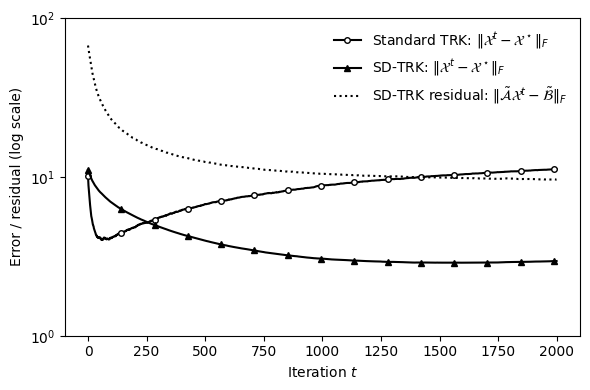

In [5]:
plt.figure(figsize=(6, 4))
plt.semilogy(paired['trk'], color='black', marker='o', markerfacecolor='white',
             markevery=T // 14, markersize=4, linewidth=1.5,
             label=r'Standard TRK: $\|\mathcal{X}^t - \mathcal{X}^\star\|_F$')
plt.semilogy(paired['sd'], color='black', marker='^',
             markevery=T // 14, markersize=4, linewidth=1.5,
             label=r'SD-TRK: $\|\mathcal{X}^t - \mathcal{X}^\star\|_F$')
plt.semilogy(paired['resid'], color='black', linestyle=':', linewidth=1.5,
             label=r'SD-TRK residual: $\|\tilde{\mathcal{A}} \mathcal{X}^t - \tilde{\mathcal{B}}\|_F$')
plt.xlabel(r'Iteration $t$')
plt.ylabel('Error / residual (log scale)')
ax = plt.gca()
ax.set_ylim(1e0, 1e2)
ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=4))
ax.yaxis.set_minor_locator(mticker.NullLocator())
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('known_target_comparison.png', dpi=300, bbox_inches='tight')
plt.show()